In [ ]:
import sys
sys.path.insert(0, '../lib')

import os
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad
import pynndescent
import numba
import seaborn as sns
import torch
import pytorch_lightning.loggers
import rapids_singlecell as rsc
import sc_utils

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


# Initial clustering

### Load HVG object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '04scVI_1000hvg_10-2.h5ad')

### Load model

In [3]:
vae = scvi.model.SCVI.load("06_scvi_1000_10.model/", adata)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/lightning/fabric/plugins/environments/slurm.py:168: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python3.10 /projects/b1196/envs/serniczek/lib/python3.10/si ...


INFO     File 06_scvi_1000_10.model/model.pt already downloaded                                                    


/projects/b1196/envs/serniczek/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


### Get model output

In [4]:
adata.obsm["X_scVI"] = vae.get_latent_representation(adata)

/projects/b1196/envs/serniczek/lib/python3.10/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


### Visualization with scanpy

In [5]:
sc.pp.neighbors(adata, use_rep="X_scVI")

In [6]:
rsc.tl.umap(adata, min_dist=0.3)

In [7]:
rsc.tl.leiden(adata, key_added="cell_type", resolution=0.75)

In [8]:
len(adata.obs.cell_type.unique().tolist())

44

In [9]:
adata

AnnData object with n_obs × n_vars = 2491432 × 1000
    obs: 'name', 'library_id', 'individual', 'protocol', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mito', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'cell_type_colors', 'hvg', 'leiden', 'library_id_colors', 'neighbors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'cell_type'}, xlabel='UMAP1', ylabel='UMAP2'>

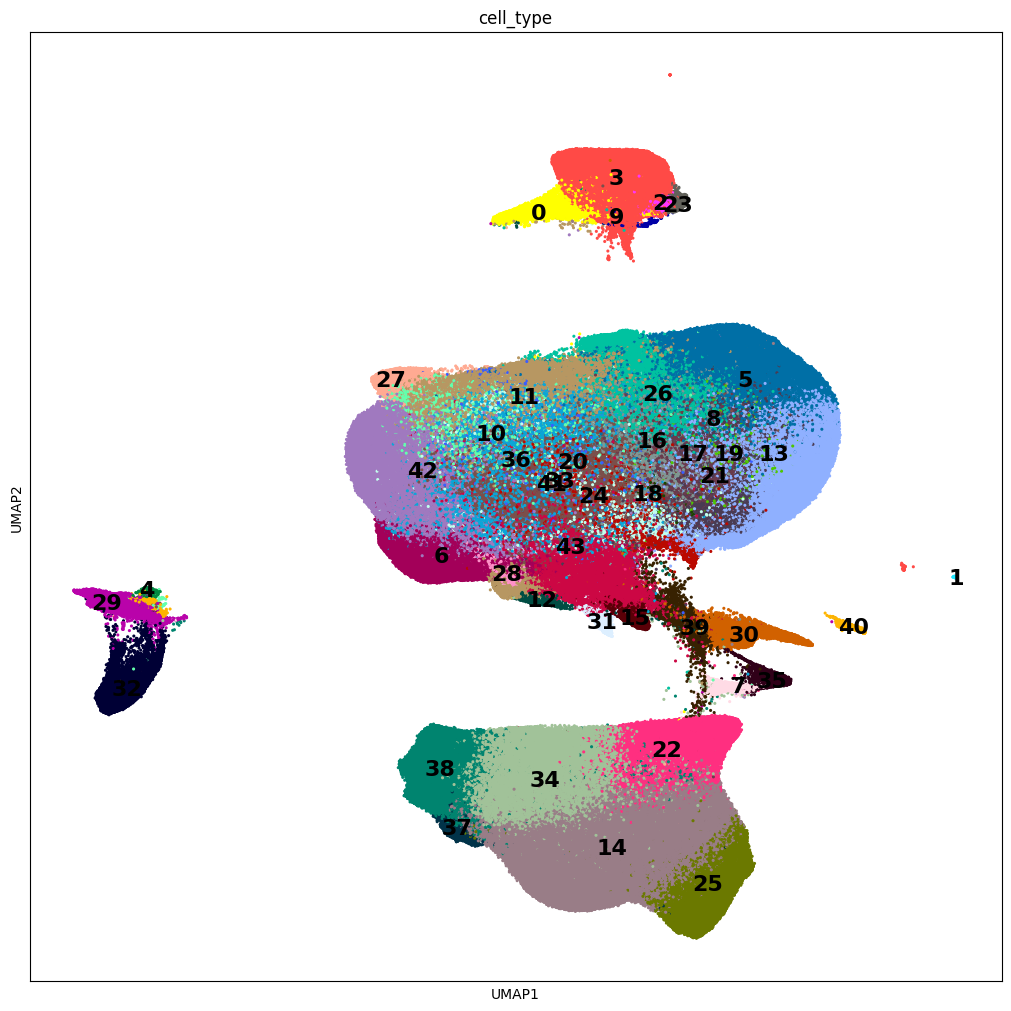

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10), constrained_layout=True)
sc.pl.embedding(
    adata,
    basis="umap",
    color="cell_type",
    legend_loc="on data",
    size=20,
    ax=ax,
    show=False,
    legend_fontsize=16
)

In [ ]:
adata.write_h5ad(common_data._sc_root / '07a_hvg1000_clustered.h5ad')

### Total counts per cell

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


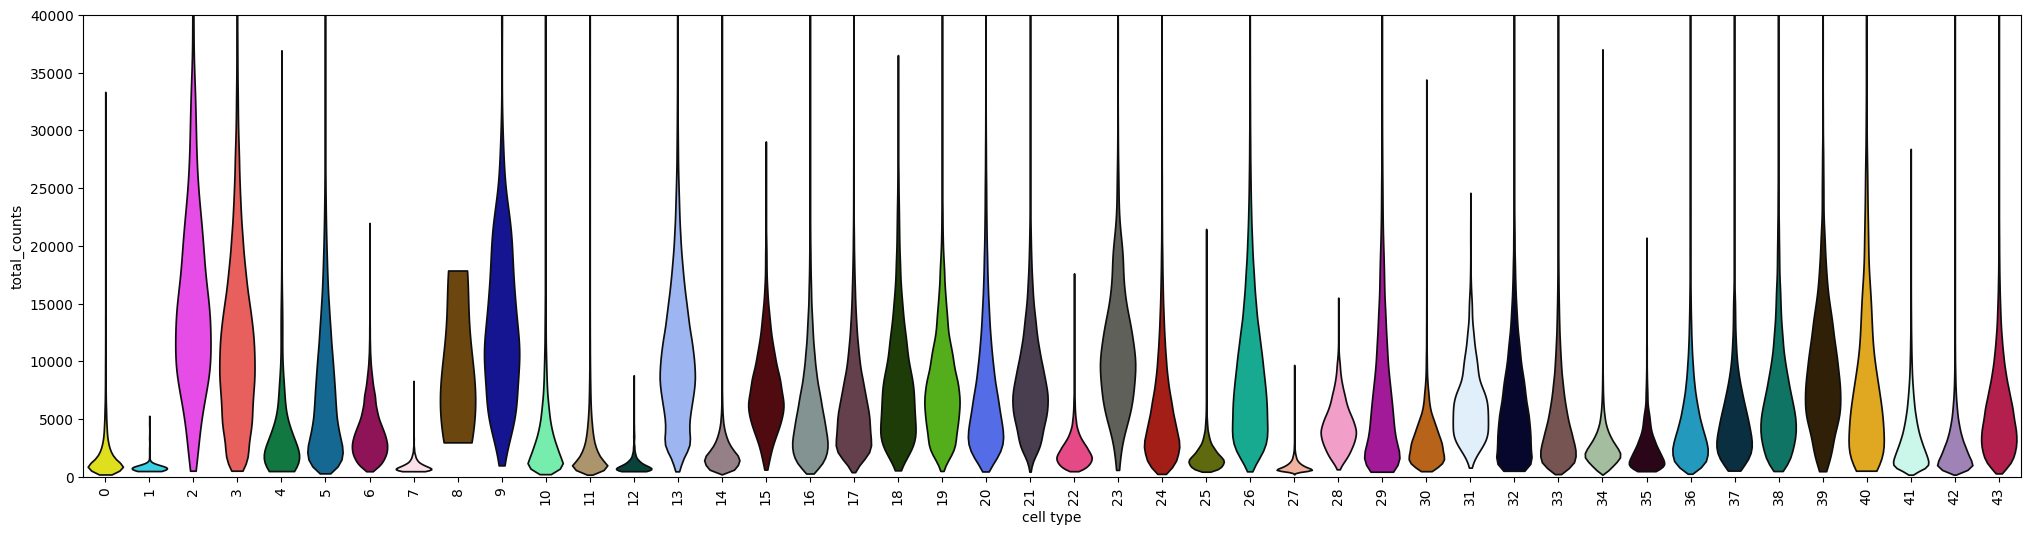

In [12]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "total_counts", groupby="cell_type", size=0, ax=ax, show=False)
# ax.axhline(500, c="red", lw=1)
ax.set_ylim(0, 40000)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

### Number of expressed genes in a cell

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


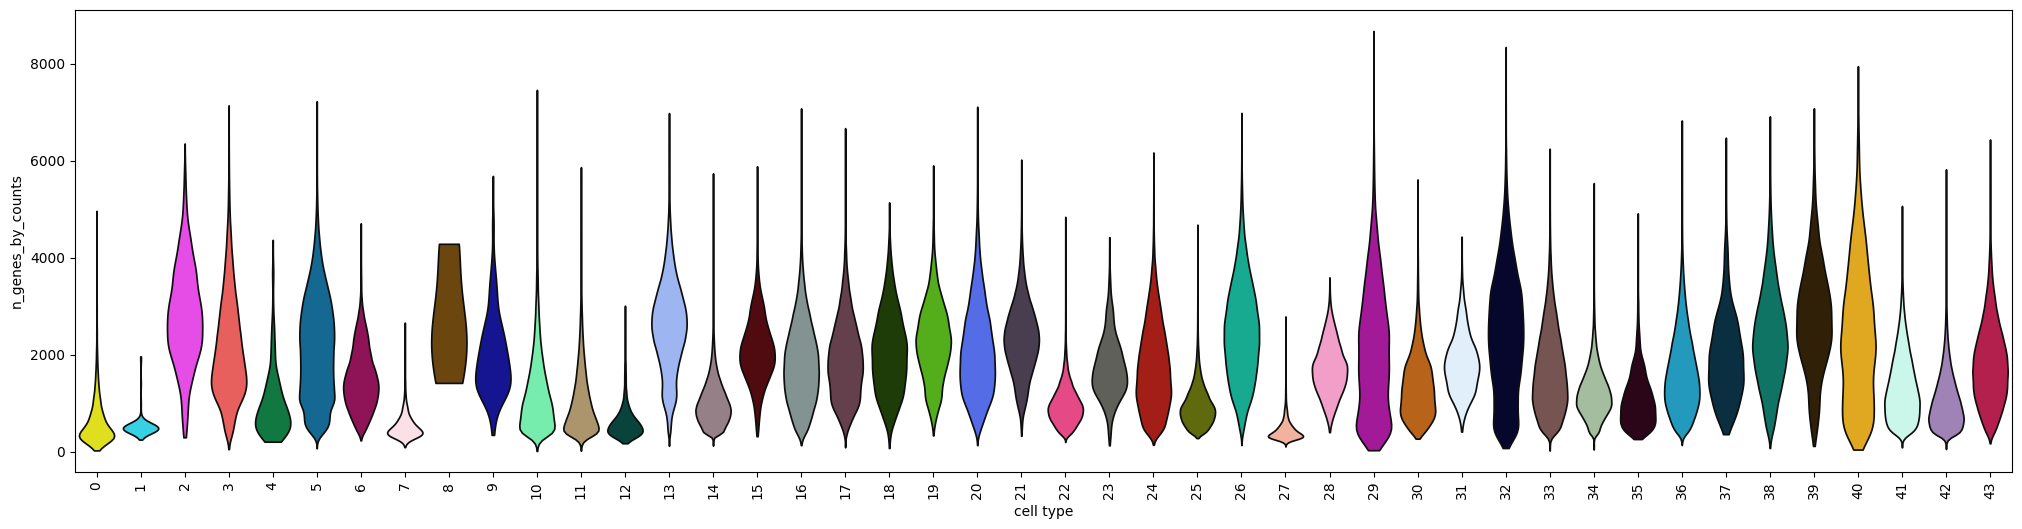

In [13]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "n_genes_by_counts", groupby="cell_type", size=0, ax=ax, show=False)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

### Percentage of counts in mitochondrial genes

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_anndata.py:842: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


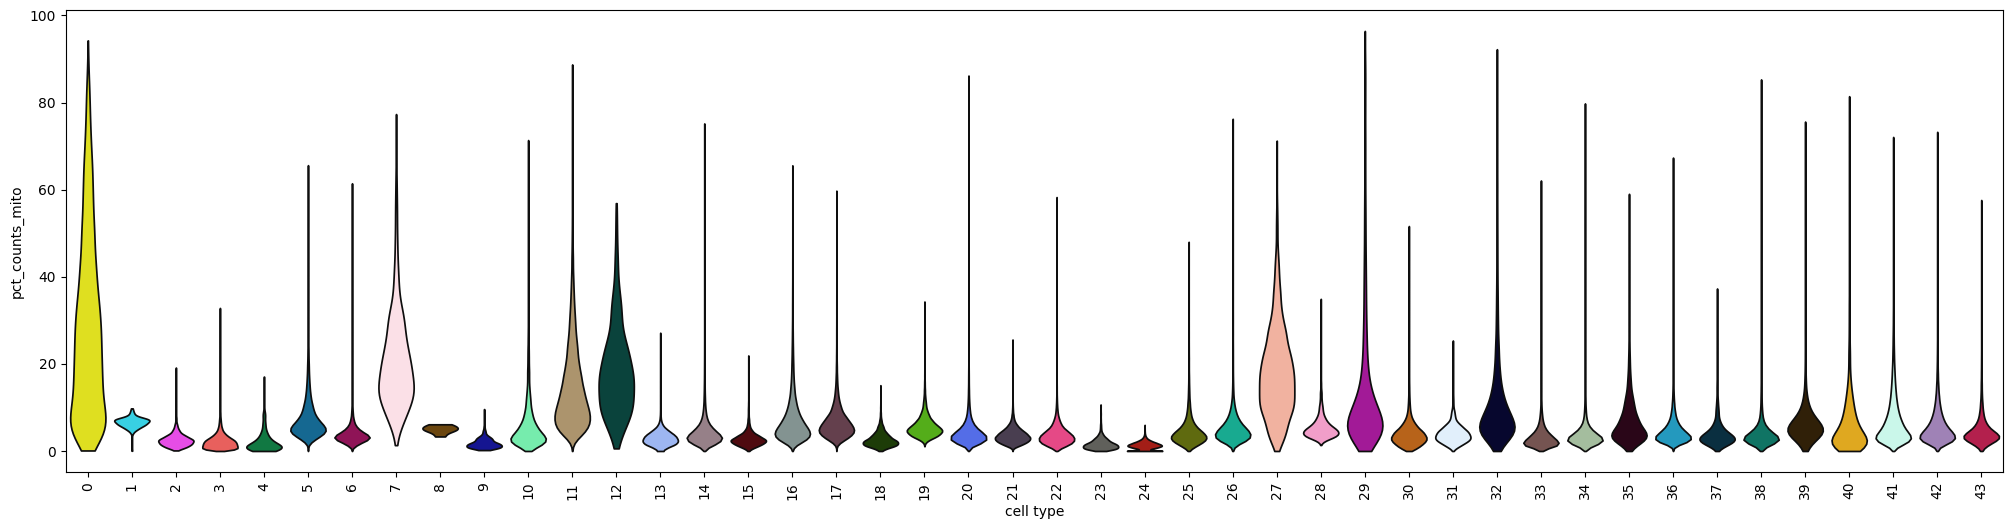

In [15]:
fig, ax = plt.subplots(figsize=(25, 6))
sc.pl.violin(adata, "pct_counts_mito", groupby="cell_type", size=0, ax=ax, show=False)
# ax.axhline(500, c="red", lw=1)
trans = mpl.transforms.Affine2D().translate(6, 0)
for t in ax.get_xticklabels():
    t.set_size(10)
    t.set_rotation(90)
    # t.set_horizontalalignment("right")
    # t.set_transform(t.get_transform() + trans)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


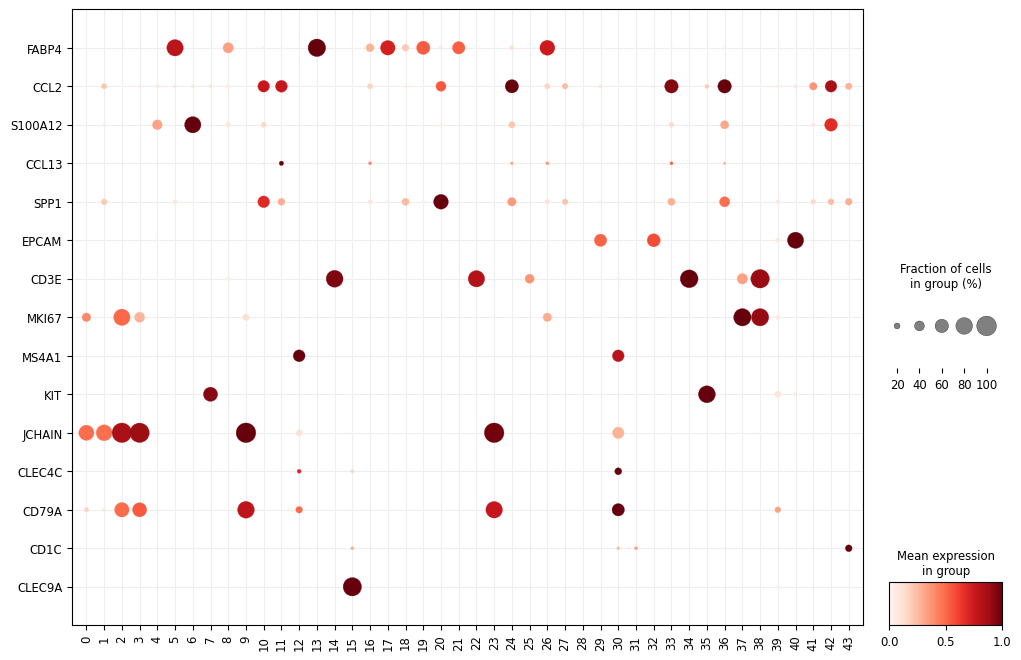

In [16]:
ax = sc.pl.dotplot(
    adata,
    ["FABP4", # TRAM
     "CCL2", # MoAM
     "S100A12", # monocytes
     "CCL13", # perivascular macs
     "SPP1", # profibrotic macs
     "EPCAM", # epithelial
     "CD3E", # T cells
     "MKI67", # proliferating
     "MS4A1", # B cells
     "KIT", # mast
     "JCHAIN", "CLEC4C", # pDC
                "CD79A", # plasma
     "CD1C", # DC2
     "CLEC9A", # DC1
     ],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)